![cnn image](https://media.geeksforgeeks.org/wp-content/uploads/20250207123959732912/Working-of-CNN_.webp)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

class TinyCNN(nn.Module):

    """A small CNN for MNIST (28×28 grayscale). Structure: Conv → Pool → Conv → Pool → FC → Output."""

    def __init__(self, num_classes=10):

        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)   # 1 channel in, 16 filters out; padding=1 keeps size

        self.pool = nn.MaxPool2d(2, 2)                # 2×2 windows, stride 2 → halves each dimension

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)  # 16 channels in, 32 out

        self.fc1 = nn.Linear(32 * 7 * 7, 128)        # After 2 pools: 28→14→7, so 7×7 spatial, 128 nodes (Hidden Layer / fc1)

        self.fc2 = nn.Linear(128, num_classes)

 

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))   # (B,16,14,14)

        x = self.pool(F.relu(self.conv2(x)))   # (B,32,7,7)

        x = x.view(x.size(0), -1)   # Flatten: (B, 32*7*7)

        x = F.relu(self.fc1(x))

        x = self.fc2(x)

        return x

In [2]:
model = TinyCNN(10)

print(model)

print("Total params:", sum(p.numel() for p in model.parameters()))

TinyCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Total params: 206922


In [3]:
# Manual 1D convolution (NumPy)

def conv1d_numpy(x, w):

    """x: (L,), w: (k,). Output length L - k + 1."""

    L, k = len(x), len(w)

    out = np.zeros(L - k + 1)

    for i in range(len(out)):

        out[i] = np.sum(x[i:i+k] * w)

    return out

 

x = np.array([1., 2., 3., 4., 5., 6., 7.])

w = np.array([0.5, -0.5])

print("1D conv output:", conv1d_numpy(x, w))

1D conv output: [-0.5 -0.5 -0.5 -0.5 -0.5 -0.5]


In [4]:
# MNIST: 28×28 grayscale digits (0–9). Normalize with dataset mean/std for stable training.

transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

test_set = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# num_workers=0: safe on Windows and Apple M (avoids multiprocessing issues)

train_loader = DataLoader(train_set, batch_size=16384, shuffle=True, num_workers=12)

test_loader = DataLoader(test_set, batch_size=16384, shuffle=False, num_workers=12)

print("MNIST train:", len(train_set), "test:", len(test_set))

MNIST train: 60000 test: 10000


In [5]:
# import torch
# import time

# # Check if CUDA is available
# if not torch.cuda.is_available():
#     print("CUDA not detected. Please check your drivers.")
# else:
#     device = torch.device("cuda")
#     print(f"Using GPU: {torch.cuda.get_device_name(0)}")

#     # 1. Initialize large matrices
#     # A 10,000 x 10,000 matrix of floats
#     size = 10000 
#     print(f"Allocating two {size}x{size} matrices on GPU...")
    
#     # Using float32 for standard precision stress
#     a = torch.randn(size, size, device=device)
#     b = torch.randn(size, size, device=device)

#     print("Starting stress test. Press Ctrl+C to stop.")
    
#     # Warm-up run
#     torch.matmul(a, b)
#     torch.cuda.synchronize()

#     try:
#         while True:
#             start_time = time.time()
            
#             # 2. Perform Matrix Multiplication
#             # We do it multiple times in a loop to keep the GPU busy
#             for _ in range(50):
#                 c = torch.matmul(a, b)
            
#             # Wait for GPU to finish so we get accurate timing
#             torch.cuda.synchronize()
            
#             end_time = time.time()
#             it_sec = 50 / (end_time - start_time)
#             print(f"Processed 50 large multiplications. Speed: {it_sec:.2f} iterations/sec", end='\r')
            
#     except KeyboardInterrupt:
#         print("\nTest stopped by user.")

In [6]:
import torch

import torch.nn as nn

import torch.optim as optim

from torch.utils.data import DataLoader

import torchvision

from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt

import numpy as np

import random

import time

import copy

from pathlib import Path

# Device selection: prioritize GPU acceleration when available

def get_device():

    """

    Automatically select the best available device.

    Priority: CUDA (NVIDIA GPU) > MPS (Apple Silicon) > CPU

    """

    if torch.cuda.is_available():

        device = torch.device("cuda")

        print(f"Using CUDA: {torch.cuda.get_device_name(0)}")

    elif torch.backends.mps.is_available():

        device = torch.device("mps")

        print("Using MPS (Apple Silicon GPU)")

    else:

        device = torch.device("cpu")

        print("Using CPU")

    return device

 

device = get_device()

Using CUDA: NVIDIA GeForce RTX 4060


In [7]:
def set_seed(seed=42):

    """Set random seeds for reproducibility across all libraries."""

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)

        torch.cuda.manual_seed_all(seed)

    # For deterministic behavior (may slow down training)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False

 

set_seed(42)

In [8]:
# ImageNet normalization values (used for all pretrained models)

# Mean and SD of pixel values across all ImageNet images for each color channel (R, G, B)

IMAGENET_MEAN = [0.485, 0.456, 0.406]

IMAGENET_STD = [0.229, 0.224, 0.225]

 

# Transforms for training data (with augmentation)

train_transforms = transforms.Compose([

    transforms.Resize(224),              # Resize to 224x224 for pretrained models

    transforms.RandomHorizontalFlip(),   # Simple augmentation

    transforms.ToTensor(),               # Convert to tensor [0, 1]

    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)  # ImageNet normalization

])



# Transforms for validation/test data (no augmentation)

val_transforms = transforms.Compose([

    transforms.Resize(224),

    transforms.ToTensor(),

    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

])

In [9]:
# Download and prepare datasets

print("Downloading CIFAR-10 dataset...")

train_dataset = datasets.CIFAR10(

    root='./data',

    train=True,

    download=True,

    transform=train_transforms

)

 

val_dataset = datasets.CIFAR10(

    root='./data',

    train=False,

    download=True,

    transform=val_transforms

)

 

# CIFAR-10 class names

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',

               'dog', 'frog', 'horse', 'ship', 'truck']

num_classes = len(class_names)

 

print(f"Training samples: {len(train_dataset)}")

print(f"Validation samples: {len(val_dataset)}")

print(f"Number of classes: {num_classes}")

c:\coding\python\assignments\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 50000
Validation samples: 10000
Number of classes: 10


In [10]:
BATCH_SIZE = 512

 

# Note: num_workers=0 for Windows compatibility; increase on Linux/Mac for speed

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,           # Shuffle training data each epoch

    num_workers=0,

    pin_memory=True if device.type == 'cuda' else False

)

 

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,          # No need to shuffle validation data

    num_workers=0,

    pin_memory=True if device.type == 'cuda' else False

)

In [11]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    """

    Train the model for one epoch.

    

    Args:

        model: PyTorch model to train

        dataloader: Training data loader

        criterion: Loss function

        optimizer: Optimizer (e.g., Adam, SGD)

        device: Device to use (cuda/mps/cpu)

    

    Returns:

        Tuple of (average_loss, accuracy)

    """

    model.train()  # Set model to training mode (enables dropout, batch norm updates)

    running_loss = 0.0

    correct = 0

    total = 0

    for inputs, labels in dataloader:

            inputs, labels = inputs.to(device), labels.to(device)

            

            optimizer.zero_grad()           # Clear previous gradients

            outputs = model(inputs)         # Forward pass

            loss = criterion(outputs, labels)

            loss.backward()                 # Compute gradients

            optimizer.step()                # Update weights

            

            running_loss += loss.item() * inputs.size(0)

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

        

    epoch_loss = running_loss / total

    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc


In [12]:
def evaluate(model, dataloader, criterion, device):

    """

    Evaluate the model on validation/test data.

    

    Args:

        model: PyTorch model to evaluate

        dataloader: Validation/test data loader

        criterion: Loss function

        device: Device to use

    

    Returns:

        Tuple of (average_loss, accuracy)

    """

    model.eval()  # Set model to evaluation mode (disables dropout, fixes batch norm)

    running_loss = 0.0

    correct = 0

    total = 0

    with torch.no_grad():  # Disable gradient computation for efficiency

            for inputs, labels in dataloader:

                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                

                running_loss += loss.item() * inputs.size(0)

                _, predicted = outputs.max(1)

                total += labels.size(0)

                correct += predicted.eq(labels).sum().item()

        

    epoch_loss = running_loss / total

    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

In [13]:
def train_model(model, train_loader, val_loader, criterion, optimizer, 

                device, num_epochs, scheduler=None, model_name="Model"):

    """

    Complete training loop with validation and history tracking.

    

    Returns:

        Tuple of (trained_model, history_dict)

    """

    # History dictionary to store loss and accuracy for each epoch

    history = {

        'train_loss': [], 'train_acc': [],

        'val_loss': [], 'val_acc': []

    }

    

    best_acc = 0.0

    best_model_weights = copy.deepcopy(model.state_dict())

    

    print(f"\n{'='*60}")

    print(f"Training: {model_name}")

    print(f"{'='*60}")

    

    start_time = time.time()
    for epoch in range(num_epochs):

        epoch_start = time.time()

        

        # Training phase

        train_loss, train_acc = train_one_epoch(

            model, train_loader, criterion, optimizer, device

        )

        

        # Validation phase

        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        

        # Update learning rate if scheduler is provided

        if scheduler:

            scheduler.step()
    
    # Save history

        history['train_loss'].append(train_loss)

        history['train_acc'].append(train_acc)

        history['val_loss'].append(val_loss)

        history['val_acc'].append(val_acc)

        

        # Save best model

        if val_acc > best_acc:

            best_acc = val_acc

            best_model_weights = copy.deepcopy(model.state_dict())

        

        epoch_time = time.time() - epoch_start

        print(f"Epoch {epoch+1:2d}/{num_epochs} | "

              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "

              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "

              f"Time: {epoch_time:.1f}s")
    
    total_time = time.time() - start_time

    print(f"\nTraining complete in {total_time/60:.1f} minutes")

    print(f"Best validation accuracy: {best_acc:.2f}%")

    

    # Load best model weights

    model.load_state_dict(best_model_weights)

    

    return model, history
    

In [14]:
def plot_curves(history, title="Training History"):

    """

    Plot training and validation loss/accuracy curves.

    

    Args:

        history: Dictionary with 'train_loss', 'val_loss', 'train_acc', 'val_acc'

        title: Plot title

    """

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    

    # Loss plot

    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')

    axes[0].plot(history['val_loss'], label='Val Loss', marker='s')

    axes[0].set_xlabel('Epoch')

    axes[0].set_ylabel('Loss')

    axes[0].set_title(f'{title} - Loss')

    axes[0].legend()

    axes[0].grid(True)

    

    # Accuracy plot

    axes[1].plot(history['train_acc'], label='Train Acc', marker='o')

    axes[1].plot(history['val_acc'], label='Val Acc', marker='s')

    axes[1].set_xlabel('Epoch')

    axes[1].set_ylabel('Accuracy (%)')

    axes[1].set_title(f'{title} - Accuracy')

    axes[1].legend()

    axes[1].grid(True)

    

    plt.tight_layout()

    plt.show()

In [15]:
def show_predictions(model, dataloader, class_names, device, num_images=8):

    """

    Display sample images with predicted and true labels.

    """

    model.eval()

    images_shown = 0

    fig, axes = plt.subplots(2, 4, figsize=(12, 6))

    axes = axes.flatten()

    

    # Denormalize for display

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)

    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    with torch.no_grad():

        for inputs, labels in dataloader:

            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)

            _, predicted = outputs.max(1)

            

            for i in range(inputs.size(0)):

                if images_shown >= num_images:

                    break

                

                # Denormalize image

                img = inputs[i].cpu() * std + mean

                img = img.permute(1, 2, 0).numpy()

                img = np.clip(img, 0, 1)

                true_label = class_names[labels[i]]

                pred_label = class_names[predicted[i]]

                color = 'green' if true_label == pred_label else 'red'

                

                axes[images_shown].imshow(img)

                axes[images_shown].set_title(f'True: {true_label}\nPred: {pred_label}', 

                                             color=color, fontsize=10)

                axes[images_shown].axis('off')

                images_shown += 1

            

            if images_shown >= num_images:

                break

    

    plt.tight_layout()

    plt.show()

In [16]:
# Load pretrained ResNet18

# weights=IMAGENET1K_V1 loads the ImageNet pretrained weights

feature_extractor = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

 

# Examine the model structure (helps understand what to modify)

print("Original ResNet18 final layer (fc):")

print(feature_extractor.fc)

Original ResNet18 final layer (fc):
Linear(in_features=512, out_features=1000, bias=True)


In [17]:
# STEP 1: Freeze all pretrained layers

# When requires_grad=False, the layer's weights won't be updated during training

for param in feature_extractor.parameters():

    param.requires_grad = False

 

# STEP 2: Replace the final fully connected layer

# ResNet18's fc layer expects 512 input features, outputs 1000 (ImageNet classes)

# We replace it with a new layer that outputs num_classes (10 for CIFAR-10)

num_features = feature_extractor.fc.in_features  # Get input size (512 for ResNet18)

feature_extractor.fc = nn.Linear(num_features, num_classes)  # New layer, trainable by default

 

print(f"New final layer: Linear({num_features}, {num_classes})")

New final layer: Linear(512, 10)


In [18]:
# Move model to device

feature_extractor = feature_extractor.to(device)

 

# Count trainable vs total parameters

total_params = sum(p.numel() for p in feature_extractor.parameters())

trainable_params = sum(p.numel() for p in feature_extractor.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")

print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")

Total parameters: 11,181,642
Trainable parameters: 5,130 (0.05%)


In [19]:
# STEP 3: Set up optimizer - only optimize the new head (fc layer)

# Since other layers are frozen, we only need to pass the trainable parameters

criterion = nn.CrossEntropyLoss()

optimizer_fe = optim.Adam(feature_extractor.fc.parameters(), lr=0.001)

 

# Train the feature extractor

FEATURE_EXTRACTOR_EPOCHS = 5

 

feature_extractor, fe_history = train_model(

    model=feature_extractor,

    train_loader=train_loader,

    val_loader=val_loader,

    criterion=criterion,

    optimizer=optimizer_fe,

    device=device,

    num_epochs=FEATURE_EXTRACTOR_EPOCHS,

    model_name="ResNet18 Feature Extractor (Frozen)"

)


Training: ResNet18 Feature Extractor (Frozen)
Epoch  1/5 | Train Loss: 1.2573 Acc: 61.66% | Val Loss: 0.8256 Acc: 75.35% | Time: 86.3s
Epoch  2/5 | Train Loss: 0.7338 Acc: 76.98% | Val Loss: 0.6877 Acc: 77.95% | Time: 84.5s
Epoch  3/5 | Train Loss: 0.6509 Acc: 78.60% | Val Loss: 0.6446 Acc: 78.64% | Time: 87.5s
Epoch  4/5 | Train Loss: 0.6104 Acc: 79.63% | Val Loss: 0.6156 Acc: 79.57% | Time: 89.2s
Epoch  5/5 | Train Loss: 0.5888 Acc: 80.12% | Val Loss: 0.6020 Acc: 79.91% | Time: 89.4s

Training complete in 7.3 minutes
Best validation accuracy: 79.91%


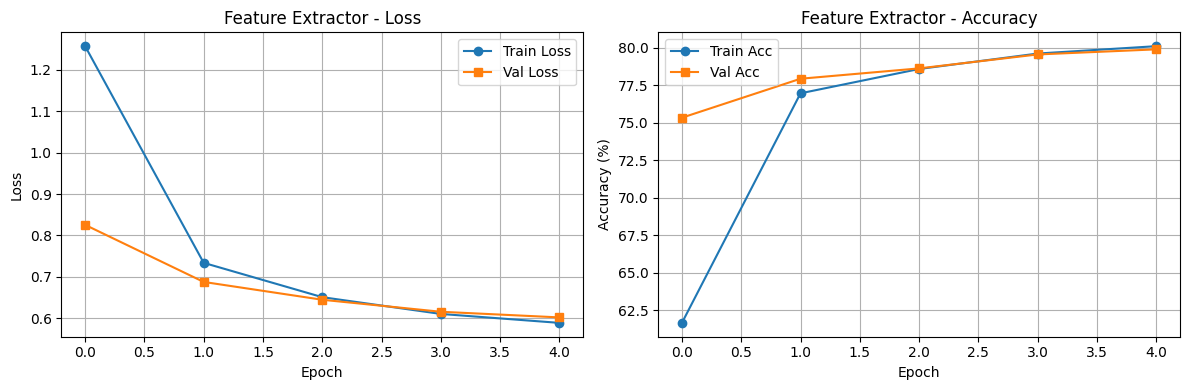

In [20]:
plot_curves(fe_history, "Feature Extractor")
# Start fresh with a new pretrained model

fine_tuned_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

 

# Replace the final layer first

num_features = fine_tuned_model.fc.in_features

fine_tuned_model.fc = nn.Linear(num_features, num_classes)


In [21]:
# STRATEGY: Unfreeze layer4 and fc, keep everything else frozen

# This gives us the best balance of pretrained knowledge and adaptability

 

# First, freeze everything

for param in fine_tuned_model.parameters():

    param.requires_grad = False

 

# Unfreeze layer4 (the last residual block)

for param in fine_tuned_model.layer4.parameters():

    param.requires_grad = True

 

# Unfreeze fc (our new classification head) - already unfrozen since we just created it

for param in fine_tuned_model.fc.parameters():

    param.requires_grad = True

 

fine_tuned_model = fine_tuned_model.to(device)

In [22]:


# Count parameters again

total_params = sum(p.numel() for p in fine_tuned_model.parameters())

trainable_params = sum(p.numel() for p in fine_tuned_model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")

print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")

Total parameters: 11,181,642
Trainable parameters: 8,398,858 (75.11%)


In [23]:
# DIFFERENT LEARNING RATES for different parameter groups

# Lower LR for pretrained layers (0.0001) - they're already well-trained

# Higher LR for new head (0.001) - needs to learn from scratch

 

# Create parameter groups with different learning rates

optimizer_ft = optim.Adam([

    {'params': fine_tuned_model.layer4.parameters(), 'lr': 0.0001},  # Lower LR for pretrained

    {'params': fine_tuned_model.fc.parameters(), 'lr': 0.001}        # Higher LR for new head

])

 

print("Learning rates:")

print("  - layer4 (pretrained): 0.0001")

print("  - fc (new head): 0.001")

Learning rates:
  - layer4 (pretrained): 0.0001
  - fc (new head): 0.001



Training: ResNet18 Fine-Tuned (layer4 + fc)
Epoch  1/5 | Train Loss: 0.4638 Acc: 84.56% | Val Loss: 0.3382 Acc: 88.31% | Time: 95.8s
Epoch  2/5 | Train Loss: 0.2364 Acc: 92.04% | Val Loss: 0.2986 Acc: 89.66% | Time: 96.3s
Epoch  3/5 | Train Loss: 0.1498 Acc: 95.20% | Val Loss: 0.2838 Acc: 90.44% | Time: 97.5s
Epoch  4/5 | Train Loss: 0.0887 Acc: 97.51% | Val Loss: 0.2743 Acc: 90.92% | Time: 97.7s
Epoch  5/5 | Train Loss: 0.0611 Acc: 98.50% | Val Loss: 0.2836 Acc: 90.87% | Time: 98.1s

Training complete in 8.1 minutes
Best validation accuracy: 90.92%


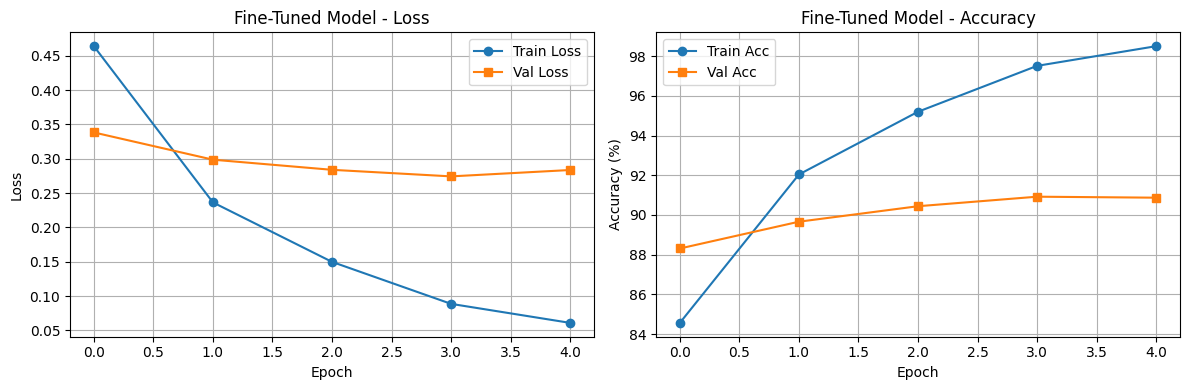

In [25]:
# Optional: Learning rate scheduler to reduce LR over time

scheduler_ft = optim.lr_scheduler.StepLR(optimizer_ft, step_size=3, gamma=0.5)

 

# Train the fine-tuned model

FINE_TUNE_EPOCHS = 5

 

fine_tuned_model, ft_history = train_model(

    model=fine_tuned_model,

    train_loader=train_loader,

    val_loader=val_loader,

    criterion=criterion,

    optimizer=optimizer_ft,

    device=device,

    num_epochs=FINE_TUNE_EPOCHS,

    scheduler=scheduler_ft,

    model_name="ResNet18 Fine-Tuned (layer4 + fc)"

)
plot_curves(ft_history, "Fine-Tuned Model")

In [26]:
# Get final validation accuracies

fe_val_acc = fe_history['val_acc'][-1]

ft_val_acc = ft_history['val_acc'][-1]

 

print("="*60)

print("RESULTS COMPARISON")

print("="*60)

print(f"\nFinal Validation Accuracy:")

print(f"  1. Feature Extractor (frozen):    {fe_val_acc:.2f}%")

print(f"  2. Fine-tuned (layer4 + fc):      {ft_val_acc:.2f}%")

print(f"\nImprovement from fine-tuning: {ft_val_acc - fe_val_acc:+.2f}%")

RESULTS COMPARISON

Final Validation Accuracy:
  1. Feature Extractor (frozen):    79.91%
  2. Fine-tuned (layer4 + fc):      90.87%

Improvement from fine-tuning: +10.96%


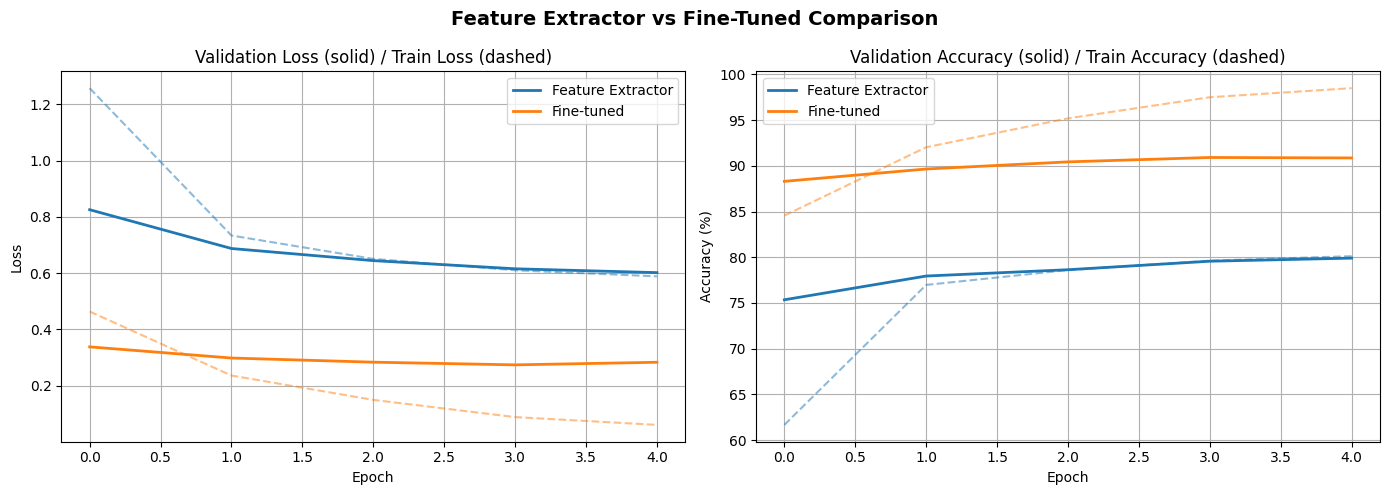

Sample predictions from fine-tuned model:


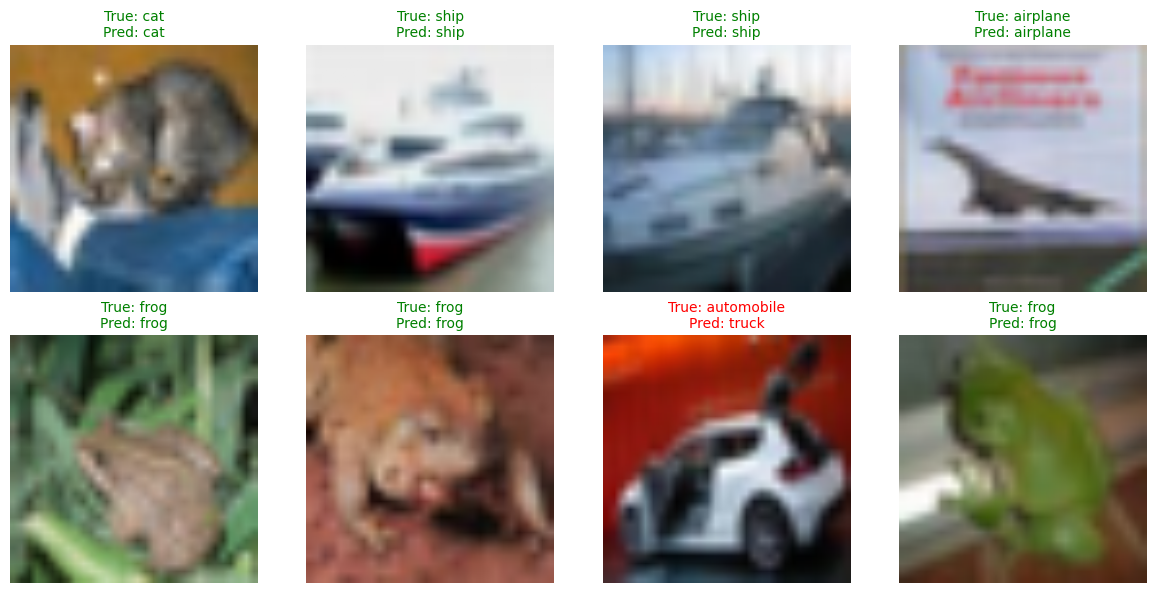

In [28]:
def plot_comparison(histories, labels, title="Model Comparison"):
    """Plot multiple training histories for comparison."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    for i, (history, label) in enumerate(zip(histories, labels)):
        # Loss
        axes[0].plot(history['train_loss'], '--', color=colors[i], alpha=0.5)
        axes[0].plot(history['val_loss'], '-', color=colors[i], label=label, linewidth=2)
        
        # Accuracy
        axes[1].plot(history['train_acc'], '--', color=colors[i], alpha=0.5)
        axes[1].plot(history['val_acc'], '-', color=colors[i], label=label, linewidth=2)
    
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Validation Loss (solid) / Train Loss (dashed)')
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Validation Accuracy (solid) / Train Accuracy (dashed)')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_comparison(
    [fe_history, ft_history],
    ['Feature Extractor', 'Fine-tuned'],
    "Feature Extractor vs Fine-Tuned Comparison"
)

# Show sample predictions from the fine-tuned model
print("Sample predictions from fine-tuned model:")
show_predictions(fine_tuned_model, val_loader, class_names, device)

In [29]:
# Create a directory for saved models

save_dir = Path("saved_models")

save_dir.mkdir(exist_ok=True)

 

# METHOD 1: Save state_dict (recommended)

model_path = save_dir / "resnet18_finetuned_cifar10.pth"

torch.save(fine_tuned_model.state_dict(), model_path)

print(f"Model state_dict saved to: {model_path}")

Model state_dict saved to: saved_models\resnet18_finetuned_cifar10.pth


In [30]:
# How to load it back:

def load_model_for_inference(model_path, num_classes=10, device='cpu'):

    """

    Load a saved model for inference.

    

    Steps:

    1. Create the same architecture

    2. Load the saved weights

    3. Set to evaluation mode

    """

    # Create model with same architecture

    model = models.resnet18(weights=None)  # No pretrained weights

    model.fc = nn.Linear(model.fc.in_features, num_classes)

    

    # Load saved weights

    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))

    

    # Set to evaluation mode (disables dropout, etc.)

    model.eval()

    model = model.to(device)

    

    return model

# Demonstrate loading

print("Loading model from disk...")

loaded_model = load_model_for_inference(model_path, num_classes=num_classes, device=device)

 

# Verify it works

val_loss, val_acc = evaluate(loaded_model, val_loader, criterion, device)

print(f"Loaded model validation accuracy: {val_acc:.2f}%")

Loading model from disk...
Loaded model validation accuracy: 90.92%


In [31]:
# METHOD 2: Save with additional metadata (useful for resuming training)

checkpoint_path = save_dir / "checkpoint.pth"

checkpoint = {

    'model_state_dict': fine_tuned_model.state_dict(),

    'optimizer_state_dict': optimizer_ft.state_dict(),

    'epoch': FINE_TUNE_EPOCHS,

    'best_val_acc': ft_val_acc,

    'class_names': class_names,

}

torch.save(checkpoint, checkpoint_path)

print(f"Full checkpoint saved to: {checkpoint_path}")

Full checkpoint saved to: saved_models\checkpoint.pth


In [32]:
### Loading a Checkpoint to Resume Training

 

# checkpoint = torch.load(checkpoint_path)

# model.load_state_dict(checkpoint['model_state_dict'])

# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# start_epoch = checkpoint['epoch']

In [33]:
def predict_single_image(model, image_tensor, class_names, device):

    """

    Predict class for a single image tensor.

    

    Args:

        model: Trained model (in eval mode)

        image_tensor: Preprocessed image tensor [C, H, W]

        class_names: List of class names

        device: Device to use

    

    Returns:

        Tuple of (predicted_class, confidence)

    """

    model.eval()

    

    # Add batch dimension: [C, H, W] -> [1, C, H, W]

    image_batch = image_tensor.unsqueeze(0).to(device)

    

    with torch.no_grad():

        outputs = model(image_batch)

        probabilities = torch.nn.functional.softmax(outputs, dim=1)

        confidence, predicted_idx = probabilities.max(1)

    

    predicted_class = class_names[predicted_idx.item()]

    confidence = confidence.item() * 100

    

    return predicted_class, confidence
# Example: predict on a validation image

sample_image, true_label = val_dataset[0]

predicted_class, confidence = predict_single_image(

    loaded_model, sample_image, class_names, device

)

print(f"Example inference:")

print(f"  True label: {class_names[true_label]}")

print(f"  Predicted: {predicted_class} ({confidence:.1f}% confidence)")






Example inference:
  True label: cat
  Predicted: cat (99.0% confidence)
